<a href="https://colab.research.google.com/github/dongtotong/sumin/blob/main/1)%20XML_%EC%A0%84%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📂 프로젝트 데이터 및 모델 리소스
본 프로젝트에 사용된 데이터셋과 학습된 최종 모델은 아래의 구글 드라이브 링크에서 확인하실 수 있습니다.

*   전체 데이터셋: https://drive.google.com/drive/folders/1pFhnW_NjIJSQ4u-Ftdckhu0wB3D0Hkfo?usp=sharing
*   XML 전처리 후 새로 생성된 데이터: https://drive.google.com/drive/folders/1yHzS3VxbEfiykrtKH0cgOMbZyz9h5Yzw?usp=sharing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import cv2
from tqdm import tqdm

BASE = '/content/drive/MyDrive/인공지능 팀플'
IMG_DIR = os.path.join(BASE, 'Dataset_Images')
XML_DIR = os.path.join(BASE, 'Dataset_XML')
NEW_MASK_DIR = os.path.join(BASE, 'Dataset_Masks_New')

os.makedirs(NEW_MASK_DIR, exist_ok=True)

In [ ]:
# 클래스별 색상(BGR), ID 매핑
COLOR_MAP = {
    'background':        (0,   0,   0),
    'sidewalk':          (255, 64,  128),
    'alley':             (192, 0,   0),
    'roadway':           (128, 0,   64),
    'bike_lane':         (192, 128, 0),
    'braille_guide_blocks': (64, 64, 0),
    'sidewalk_damaged':  (0,   128, 255),
    'caution_stairs':    (0,   0,   255),
    'caution_manhole':   (0,   255, 255),
    'caution_grating':   (128, 255, 0),
    'caution_repair_zone': (128, 0, 255),
}

CLASS_ID = {k: i for i, k in enumerate(COLOR_MAP.keys())}

for name, idx in CLASS_ID.items():
    print(f"  {idx}: {name}")

  0: background
  1: sidewalk
  2: alley
  3: roadway
  4: bike_lane
  5: braille_guide_blocks
  6: sidewalk_damaged
  7: caution_stairs
  8: caution_manhole
  9: caution_grating
  10: caution_repair_zone


In [ ]:
# XML에서 폴리곤 좌표와 라벨 추출
def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    result = {}
    for image_tag in root.iter('image'):
        img_name = image_tag.attrib['name']
        width    = int(image_tag.attrib['width'])
        height   = int(image_tag.attrib['height'])
        polygons = []
        for poly in image_tag.iter('polygon'):
            label = poly.attrib['label']

            attr = None
            for att in poly.iter('attribute'):
                attr = att.text.strip()

            final_label = get_final_label(label, attr)

            pts_str = poly.attrib['points']
            pts = []
            for pt in pts_str.split(';'):
                x, y = pt.strip().split(',')
                pts.append([float(x), float(y)])
            pts = np.array(pts, dtype=np.int32)

            polygons.append({'label': final_label,'points': pts})
        result[img_name] = {'width': width, 'height': height,'polygons': polygons}
    return result

# 속성값을 반영한 최종 클래스명 결정
def get_final_label(label, attr):
    if label == 'caution_zone':
        if attr in ['stairs', 'manhole', 'grating', 'repair_zone']:
            return f'caution_{attr}'
        else:
            return 'caution_repair_zone'

    if label == 'sidewalk' and attr == 'damaged':
        return 'sidewalk_damaged'

    if label in COLOR_MAP:
        return label

    return 'background'

In [ ]:
# 폴리곤 정보를 이용해 마스크 이미지 생성
def create_mask(img_info):
    h = img_info['height']
    w = img_info['width']

    mask = np.zeros((h, w, 3), dtype=np.uint8)

    for poly in img_info['polygons']:
        color = COLOR_MAP[poly['label']]
        cv2.fillPoly(mask, [poly['points']], color=color)

    return mask

In [ ]:
# XML 파일 전체 처리(마스크 이미지 생성, 저장)
xml_files = sorted([f for f in os.listdir(XML_DIR) if f.endswith('.xml')])
print(f"XML 파일 {len(xml_files)}개 발견\n")

total = 0
for xml_file in xml_files:
    xml_path = os.path.join(XML_DIR, xml_file)
    print(f"처리 중: {xml_file}")

    data = parse_xml(xml_path)

    for img_name, img_info in tqdm(data.items()):

        mask = create_mask(img_info)

        save_name = img_name.replace('.jpg', '.png')
        save_path = os.path.join(NEW_MASK_DIR, save_name)
        cv2.imwrite(save_path, mask)
        total += 1

print(f"\n완료! 총 {total}개 마스크 생성됨")
print(f"저장 위치: {NEW_MASK_DIR}")

XML 파일 20개 발견

처리 중: 15_SM0915_01.xml


100%|██████████| 119/119 [00:04<00:00, 24.25it/s]


처리 중: 16_SM0915_02.xml


100%|██████████| 113/113 [00:06<00:00, 18.01it/s]


처리 중: 17_SM0915_03.xml


...

처리 중: 33_SM0915_19.xml


100%|██████████| 116/116 [00:06<00:00, 18.94it/s]


처리 중: 34_SM0915_20.xml


100%|██████████| 116/116 [00:05<00:00, 20.40it/s]


완료! 총 2311개 마스크 생성됨
저장 위치: /content/drive/MyDrive/인공지능 팀플/Dataset_Masks_New


/tmp/ipykernel_3218/3836141640.py:15: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3218/3836141640.py:15: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3218/3836141640.py:15: UserWarning: Glyph 49352 (\N{HANGUL SYLLABLE SAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3218/3836141640.py:15: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3218/3836141640.py:15: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3218/3836141640.py:15: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from

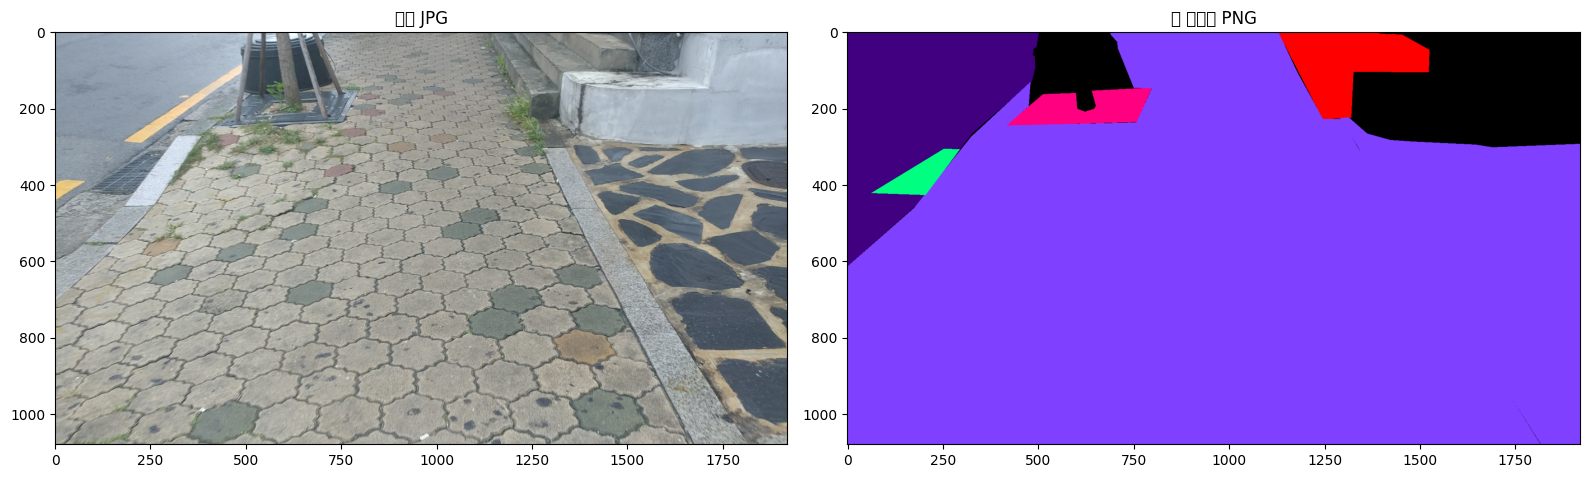

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sample_name = 'MP_SEL_SUR_000003'

img  = Image.open(os.path.join(IMG_DIR, f'{sample_name}.jpg'))
mask = Image.open(os.path.join(NEW_MASK_DIR, f'{sample_name}.png'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img)
axes[0].set_title('원본 JPG')
axes[1].imshow(mask)
axes[1].set_title('새 마스크 PNG')
plt.tight_layout()
plt.show()